# Trabalho Prático 03 — Classificação com MLPClassifier

**Disciplina:** GCC 128 — Inteligência Artificial  
**Instituição:** Universidade Federal de Lavras (UFLA)  
**Docente:** Prof. Ahmed Ali Abdalla Esmin  
**Discentes:** Caio Bueno Finocchio Martins e Lana da Silva Miranda


## 1. Imports e Configurações

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris, load_wine
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 22


## 2. Iris

A base Iris reúne medidas de sépalas e pétalas de três espécies. Os dados são divididos em conjuntos de treino e teste, mantendo a proporção entre as classes. As características são padronizadas antes do treinamento do MLPClassifier.


### 2.1 Carregamento e preparação dos dados

In [14]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris,
    y_iris,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_iris,
)

scaler_iris = StandardScaler()
X_iris_train_scaled = scaler_iris.fit_transform(X_iris_train)
X_iris_test_scaled = scaler_iris.transform(X_iris_test)

print(f"Base: {X_iris.shape[0]} amostras, {X_iris.shape[1]} atributos")
print(f"Amostras de treino: {len(X_iris_train)}")
print(f"Amostras de teste: {len(X_iris_test)}")


Base: 150 amostras, 4 atributos
Amostras de treino: 105
Amostras de teste: 45


### 2.2 Treinamento e predições

In [3]:
mlp_iris = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",             # Ajuda a evitar o problema do desaparecimento do gradiente (vanishing gradient) que afeta funções como sigmoide e tangente hiperbólica.
    solver="lbfgs",
    max_iter=200,
    random_state=RANDOM_STATE,
)
mlp_iris.fit(X_iris_train_scaled, y_iris_train)
y_iris_pred = mlp_iris.predict(X_iris_test_scaled)

print("Predições:", y_iris_pred)


Predições: [0 2 0 0 1 1 1 0 2 0 2 0 0 1 0 1 2 0 0 2 0 1 2 1 0 1 2 0 1 1 1 2 1 2 1 2 2
 1 2 1 2 1 0 2 0]


### 2.3 Matriz de confusão e métricas

Matriz de confusão (linhas: classe real; colunas: classe prevista):


,setosa,versicolor,virginica
setosa,15,0,0
versicolor,0,14,1
virginica,0,2,13


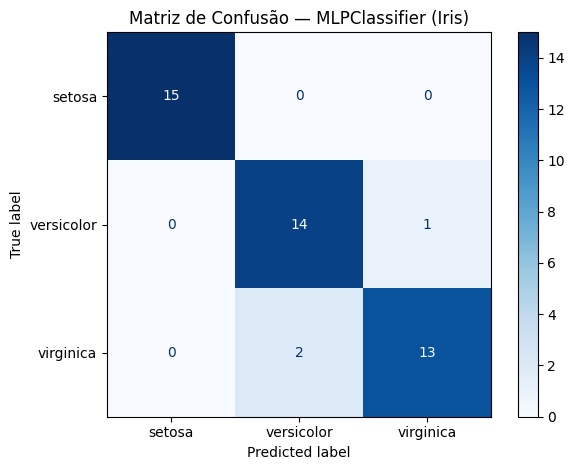

Acurácia: 93.33%
Precisão macro: 93.45%
Revocação macro: 93.33%

Relatório por classe:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



In [4]:
matriz_iris = confusion_matrix(y_iris_test, y_iris_pred)
print("Matriz de confusão (linhas: classe real; colunas: classe prevista):")
display(pd.DataFrame(matriz_iris, index=iris.target_names, columns=iris.target_names))

ConfusionMatrixDisplay(
    confusion_matrix=matriz_iris,
    display_labels=iris.target_names,
).plot(cmap=plt.cm.Blues, values_format="d")
plt.title("Matriz de Confusão — MLPClassifier (Iris)")
plt.tight_layout()
plt.show()

acuracia_iris = accuracy_score(y_iris_test, y_iris_pred)
precisao_iris = precision_score(y_iris_test, y_iris_pred, average="macro", zero_division=0)
revocacao_iris = recall_score(y_iris_test, y_iris_pred, average="macro", zero_division=0)

print(f"Acurácia: {acuracia_iris:.2%}")
print(f"Precisão macro: {precisao_iris:.2%}")
print(f"Revocação macro: {revocacao_iris:.2%}")
print("\nRelatório por classe:")
print(classification_report(y_iris_test, y_iris_pred, target_names=iris.target_names, zero_division=0))


### 2.4 Análise dos resultados

O MLPClassifier acertou todas as amostras de *setosa*. Os erros ficaram entre *versicolor* e *virginica*: duas amostras de *virginica* foram previstas como *versicolor*, e uma amostra de *versicolor* foi prevista como *virginica*. A acurácia foi 93,33%, a precisão macro 93,45% e a revocação macro 93,33%.


## 3. Wine

A base Wine contém análises químicas de vinhos pertencentes a três classes. A estrutura de preparação e avaliação é a mesma usada para Iris, com a proporção de teste de 20% definida no script atual.


### 3.1 Carregamento e preparação dos dados

In [13]:
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    X_wine,
    y_wine,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_wine,
)

scaler_wine = StandardScaler()
X_wine_train_scaled = scaler_wine.fit_transform(X_wine_train)
X_wine_test_scaled = scaler_wine.transform(X_wine_test)

print(f"Base: {X_wine.shape[0]} amostras, {X_wine.shape[1]} atributos")
print(f"Amostras de treino: {len(X_wine_train)}")
print(f"Amostras de teste: {len(X_wine_test)}")

Base: 178 amostras, 13 atributos
Amostras de treino: 142
Amostras de teste: 36


### 3.2 Treinamento e predições

In [6]:
mlp_wine = MLPClassifier(
    hidden_layer_sizes=(10,),        
    activation="relu",                
    solver="lbfgs",                   
    max_iter=500,
    random_state=RANDOM_STATE,
)
mlp_wine.fit(X_wine_train_scaled, y_wine_train)
y_wine_pred = mlp_wine.predict(X_wine_test_scaled)

print("Predições:", y_wine_pred)


Predições: [0 0 0 1 1 2 1 0 2 1 0 1 2 1 0 1 2 0 2 2 1 2 1 2 0 2 0 0 2 0 2 1 0 1 1 1]


### 3.3 Matriz de confusão e métricas

Matriz de confusão (linhas: classe real; colunas: classe prevista):


,class_0,class_1,class_2
class_0,12,0,0
class_1,0,13,1
class_2,0,0,10


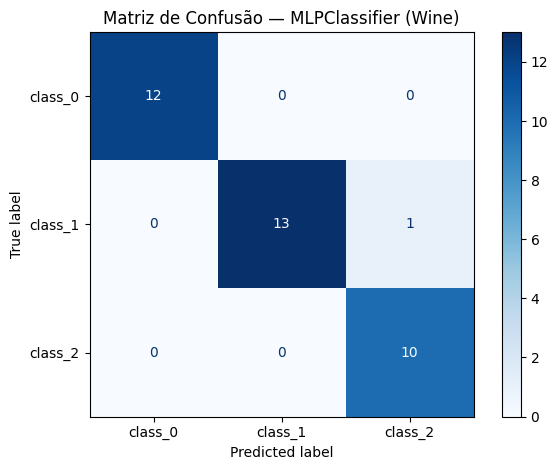

Acurácia: 97.22%
Precisão macro: 96.97%
Revocação macro: 97.62%

Relatório por classe:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      0.93      0.96        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



In [7]:
matriz_wine = confusion_matrix(y_wine_test, y_wine_pred)
print("Matriz de confusão (linhas: classe real; colunas: classe prevista):")
display(pd.DataFrame(matriz_wine, index=wine.target_names, columns=wine.target_names))

ConfusionMatrixDisplay(
    confusion_matrix=matriz_wine,
    display_labels=wine.target_names,
).plot(cmap=plt.cm.Blues, values_format="d")
plt.title("Matriz de Confusão — MLPClassifier (Wine)")
plt.tight_layout()
plt.show()

acuracia_wine = accuracy_score(y_wine_test, y_wine_pred)
precisao_wine = precision_score(y_wine_test, y_wine_pred, average="macro", zero_division=0)
revocacao_wine = recall_score(y_wine_test, y_wine_pred, average="macro", zero_division=0)

print(f"Acurácia: {acuracia_wine:.2%}")
print(f"Precisão macro: {precisao_wine:.2%}")
print(f"Revocação macro: {revocacao_wine:.2%}")
print("\nRelatório por classe:")
print(classification_report(y_wine_test, y_wine_pred, target_names=wine.target_names, zero_division=0))


### 3.4 Análise dos resultados

O MLPClassifier classificou corretamente todas as amostras das classes `class_0` e `class_2`. Uma amostra da classe `class_1` foi prevista como `class_2`. O resultado foi 97,22% de acurácia, 96,97% de precisão macro e 97,62% de revocação macro.


## 4. Comparação MLPClassifier × KNN

O notebook do trabalho anterior também avaliou o `KNeighborsClassifier` do Scikit-learn. Para observar como a quantidade de vizinhos influencia a classificação, foram avaliados `k = 1, 5, 15, 25 e 50` nas bases Iris e Wine.

Os dois classificadores usam as mesmas divisões de treino e teste em cada base, com a semente 42. O KNN recebe os atributos padronizados a partir do conjunto de treino, procedimento especialmente relevante para comparar as diferentes escalas dos atributos do Wine. A tabela apresenta acurácia, precisão macro e revocação macro para cada configuração.


### 4.1 Classificador KNN do Scikit-learn


In [8]:
def prever_knn(X_treino, y_treino, X_teste, k):
    # O parâmetro n_neighbors define quantos vizinhos participam da classificação.
    classificador = KNeighborsClassifier(n_neighbors=k)
    
    # O classificador aprende a partir dos dados de treino e seus rótulos.
    classificador.fit(X_treino, y_treino)

    # Depois, prevê os rótulos das amostras de teste, que não foram usadas no ajuste.
    return classificador.predict(X_teste)


### 4.2 Resultados nas bases Iris e Wine

In [9]:
def comparar_classificadores(nome_base, nomes_classes, y_teste, y_pred_mlp,
                              X_treino, X_teste, y_treino):
    # Registra o MLP, já treinado e avaliado na mesma divisão de treino e teste.
    resultados = [{
        "Base": nome_base,
        "Classificador": "MLPClassifier",
        "Acurácia": accuracy_score(y_teste, y_pred_mlp),
        "Precisão macro": precision_score(y_teste, y_pred_mlp, average="macro", zero_division=0),
        "Revocação macro": recall_score(y_teste, y_pred_mlp, average="macro", zero_division=0),
    }]

    # Repete a avaliação do KNN para cada valor de k definido neste experimento.
    for k in (1, 5, 15, 25, 50):
        y_pred_knn = prever_knn(X_treino, y_treino, X_teste, k)
        resultados.append({
            "Base": nome_base,
            "Classificador": f"KNN (k={k})",
            "Acurácia": accuracy_score(y_teste, y_pred_knn),
            "Precisão macro": precision_score(y_teste, y_pred_knn, average="macro", zero_division=0),
            "Revocação macro": recall_score(y_teste, y_pred_knn, average="macro", zero_division=0),
        })
    return resultados

resultados_comparacao = []
resultados_comparacao += comparar_classificadores(
    "Iris", iris.target_names, y_iris_test, y_iris_pred,
    X_iris_train_scaled, X_iris_test_scaled, y_iris_train,
)
resultados_comparacao += comparar_classificadores(
    "Wine", wine.target_names, y_wine_test, y_wine_pred,
    X_wine_train_scaled, X_wine_test_scaled, y_wine_train,
)

comparacao_df = pd.DataFrame(resultados_comparacao)
display(comparacao_df.style.format({
    "Acurácia": "{:.2%}",
    "Precisão macro": "{:.2%}",
    "Revocação macro": "{:.2%}",
}))


,Base,Classificador,Acurácia,Precisão macro,Revocação macro
0,Iris,MLPClassifier,93.33%,93.45%,93.33%
1,Iris,KNN (k=1),93.33%,93.45%,93.33%
2,Iris,KNN (k=5),93.33%,93.45%,93.33%
3,Iris,KNN (k=15),93.33%,93.45%,93.33%
4,Iris,KNN (k=25),97.78%,97.92%,97.78%
5,Iris,KNN (k=50),86.67%,86.67%,86.67%
6,Wine,MLPClassifier,97.22%,96.97%,97.62%
7,Wine,KNN (k=1),94.44%,94.41%,95.24%
8,Wine,KNN (k=5),97.22%,96.97%,97.62%
9,Wine,KNN (k=15),97.22%,96.97%,97.62%


### 4.3 Análise da comparação

Na base Iris, o melhor resultado do KNN ocorreu com `k=25`: acurácia de 97,78%, precisão macro de 97,92% e revocação macro de 97,78%. Isso corresponde a 44 acertos entre 45 amostras e supera o MLPClassifier, que acertou 42 amostras (93,33%). Com `k=1`, `k=5` e `k=15`, o KNN obteve os mesmos indicadores do MLP. Já com `k=50`, a acurácia caiu para 86,67%. Neste conjunto, aumentar `k` não melhorou o resultado de forma contínua: uma vizinhança intermediária teve o melhor desempenho, enquanto considerar muitos vizinhos parece ter suavizado demais a decisão entre as classes.

No Wine, o KNN com `k=1` teve acurácia de 94,44% (34 de 36 acertos). Para `k=5`, `k=15`, `k=25` e `k=50`, os indicadores foram iguais aos do MLPClassifier: 97,22% de acurácia, 96,97% de precisão macro e 97,62% de revocação macro, ou 35 acertos entre 36 amostras. Assim, nesta divisão, o KNN ficou estável para os valores de `k` a partir de 5, e o MLP apresentou desempenho equivalente a essas configurações.

A precisão e a revocação macro dão o mesmo peso às classes. Seus valores próximos em ambas as bases indicam que os resultados não vieram de um bom desempenho concentrado apenas em uma classe. A conclusão se refere às divisões de treino e teste usadas neste notebook; mudanças na amostragem podem alterar as métricas, especialmente porque o conjunto de teste é pequeno.
